# Find a logarithmic fit for all the urbach data

Loaded Tauc metrics: 1350 rows
Loaded chamber temperature log: 276000 rows
Loaded Urbach metrics: 1350 rows
Computed Urbach energy difference for 1350 paired entries
[20.052 20.052 20.056 ... 17.927 18.277 18.562]


/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_68839/2341958855.py:158: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg = ax.legend(handles, labels, loc='upper left', frameon=True)


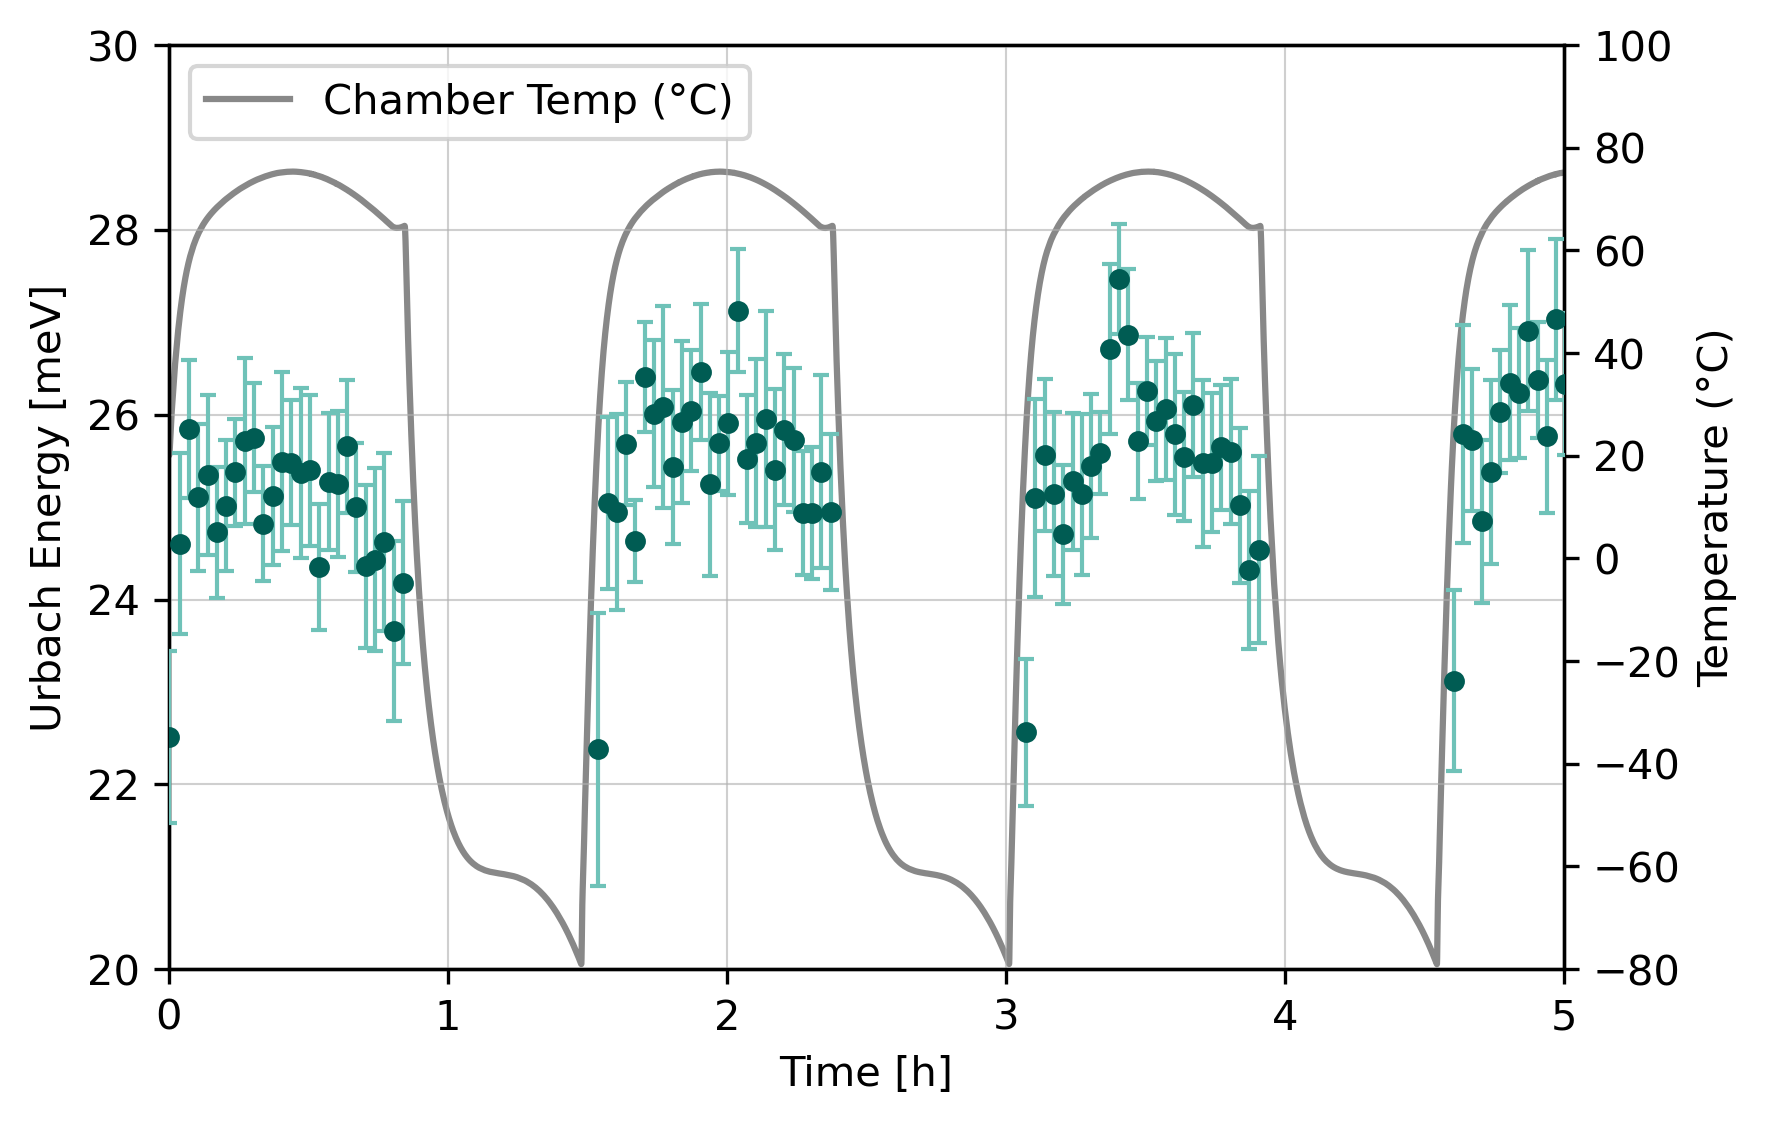

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional

tauc_file = Path(
    '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/'
    'ThermalCycling/TC_1709_50Cycle/TC_1909_IV/TC_log/tauc_metrics_test.csv'
)
temperature_file = Path(
    '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/'
    'ThermalCycling/TC_1709_50Cycle/TC_1909_IV/TC_log/temperature_log.csv'
)
urbach_file = Path(
    '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/'
    'ThermalCycling/TC_1709_50Cycle/TC_1909_IV/TC_log/urbach_metrics_test.csv'
)

required_paths = {
    'tauc metrics': tauc_file,
    'temperature log': temperature_file,
    'urbach metrics': urbach_file,
}

for label, filepath in required_paths.items():
    if not filepath.is_file():
        raise FileNotFoundError(f"Missing {label} CSV: {filepath}")

tauc_df = pd.read_csv(tauc_file)
temperature_df = pd.read_csv(temperature_file, usecols=['Elapsed_s', 'Temp_A_C'])
temperature_df.rename(columns={'Elapsed_s': 'elapsed_seconds', 'Temp_A_C': 'temperature_c'}, inplace=True)
urbach_df = pd.read_csv(urbach_file)

urbach_error = (
    urbach_df['urbach_rmse'].to_numpy() / np.sqrt(3) / 25
)

if 'band_gap' not in tauc_df.columns:
    raise KeyError("Column 'band_gap' missing from Tauc dataframe.")
if 'urbach_energy' not in urbach_df.columns:
    raise KeyError("Column 'urbach_energy' missing from Urbach dataframe.")

pair_count = min(len(tauc_df), len(urbach_df))
if pair_count == 0:
    raise ValueError('No overlapping entries available to compute Urbach energy difference.')

urbach_energy = 1/(
    urbach_df['urbach_slope'].to_numpy()
)
urbach_energy_aligned = urbach_energy[:pair_count]
urbach_error_aligned = urbach_error[:pair_count]

time_column = None
for column in tauc_df.columns:
    if 'time' in column.lower():
        time_column = column
        break

if time_column is None:
    raise KeyError("No time-related column found in Tauc dataframe for plotting.")

time_series = tauc_df[time_column]
cycles = pd.to_numeric(tauc_df.get('cycle_number_avg'), errors='coerce')
cycle_mask = np.ones(len(tauc_df), dtype=bool)

time_hours = pd.to_numeric(time_series, errors='coerce')
if not np.isfinite(time_hours.to_numpy(dtype=float)).any():
    parsed_time = pd.to_datetime(time_series, errors='coerce')
    if not parsed_time.notna().any():
        raise ValueError(
            "Could not interpret time column as numeric hours or datetimes."
        )
    origin = parsed_time.min()
    time_hours = (parsed_time - origin).dt.total_seconds() / 3600.0

time_hours = np.asarray(time_hours, dtype=float)
time_hours_aligned = time_hours[:pair_count]
cycle_mask_aligned = cycle_mask[:pair_count]

valid_mask = (
    cycle_mask_aligned
    & np.isfinite(time_hours_aligned)
    & np.isfinite(urbach_energy_aligned)
    & np.isfinite(urbach_error_aligned)
)

time_filtered = time_hours_aligned[valid_mask]
urbach_filtered = urbach_energy_aligned[valid_mask]
urbach_error_filtered = urbach_error_aligned[valid_mask]

if time_filtered.size == 0:
    raise ValueError('No valid points remain after applying the filters.')

temp_seconds = pd.to_numeric(temperature_df['elapsed_seconds'], errors='coerce')
temp_hours = np.asarray(temp_seconds, dtype=float) / 3600.0

temp_values = pd.to_numeric(temperature_df['temperature_c'], errors='coerce')
temp_values = np.asarray(temp_values, dtype=float)

temp_hours_filtered = temp_hours
temp_values_filtered = temp_values

if __name__ == '__main__':
    print(f"Loaded Tauc metrics: {len(tauc_df)} rows")
    print(f"Loaded chamber temperature log: {len(temperature_df)} rows")
    print(f"Loaded Urbach metrics: {len(urbach_df)} rows")
    print(f"Computed Urbach energy difference for {pair_count} paired entries")

    result_dir = tauc_file.parent / 'Result'
    result_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(6, 4), dpi = 300)

    # 先创建双轴
    ax_temp = ax.twinx()

    # ——关键：调整两个坐标轴的绘制层级——
    ax.set_zorder(2)          # 主轴（含散点与图例）最后绘制 → 在最上层
    ax_temp.set_zorder(1)     # 温度轴在下层
    ax.patch.set_alpha(0)     # 主轴背景透明，避免遮住灰线

    # 主轴：ΔE 散点
    scatter = ax.errorbar(
        time_filtered,
        urbach_filtered*1000,
        yerr=urbach_error_filtered*1000,
        fmt='o',
        markersize=4,
        color='#005C53',
        ecolor='#6FC2B8',
        elinewidth=1,
        capsize=2,
        label='ΔE',
        zorder=3,
    )
    scatter_handle = scatter.lines[0]

    ax.set_xlabel('Time [h]')
    ax.set_ylabel('Urbach Energy [meV]')
    #ax.set_title('Urbach Energy Difference vs Time', weight='bold')
    ax.set_xlim(0, 5)
    ax.set_ylim(20, 30)
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.6, zorder=0)

    # 右轴：温度曲线
    temp_line, = ax_temp.plot(
        temp_hours_filtered, temp_values_filtered,
        color='#888888', linewidth=1.5, label='Chamber Temp (°C)', zorder=1
    )
    ax_temp.set_ylabel('Temperature (°C)')
    ax_temp.patch.set_alpha(0)
    ax_temp.set_ylim(-80, 100)

    # 图例（现在会在最上层）
    handles = [scatter_handle, temp_line]
    labels = [h.get_label() for h in handles]
    leg = ax.legend(handles, labels, loc='upper left', frameon=True)
    leg.set_zorder(10)

    # 保存
    output_path = result_dir / 'urbach_energy_difference.png'
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    # plt.show()

    print(temp_values_filtered)


In [32]:
from scipy.optimize import curve_fit

x = time_filtered
y = urbach_filtered

def function(x, a, b):
    return a * np.log(x) + b

popt, pcov = curve_fit(function, x, y)
a, b = popt
print(f"a = {a:.3f}, b = {b:.3f}")

x_fit = np.linspace(min(x), max(x), 200)
y_fit = function(x_fit, a, b)


a = 0.001, b = 0.024


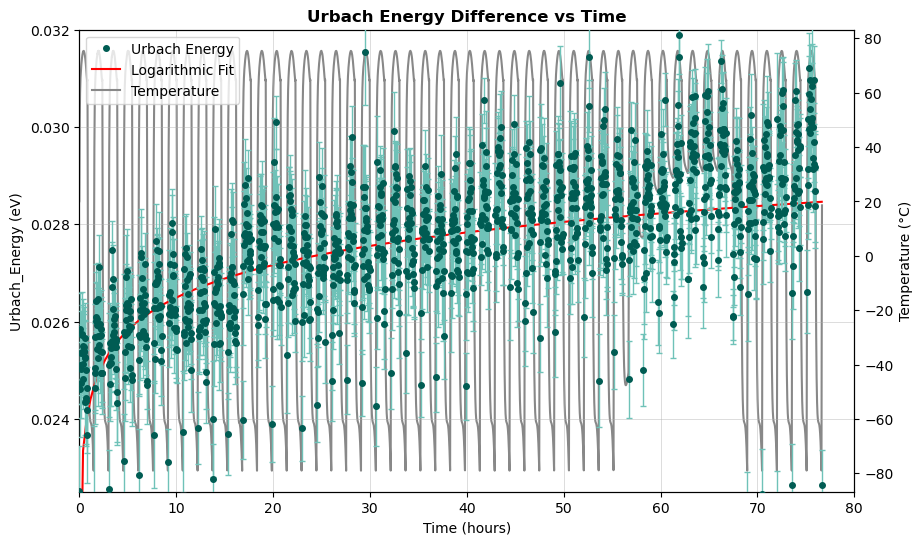

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

# 先创建双轴
ax_temp = ax.twinx()

# ——关键：调整两个坐标轴的绘制层级——
ax.set_zorder(2)          # 主轴（含散点与图例）最后绘制 → 在最上层
ax_temp.set_zorder(1)     # 温度轴在下层
ax.patch.set_alpha(0)     # 主轴背景透明，避免遮住灰线

# 主轴：ΔE 散点
scatter = ax.errorbar(
    time_filtered,
    urbach_filtered,
    yerr=urbach_error_filtered,
    fmt='o',
    markersize=4,
    color='#005C53',
    ecolor='#6FC2B8',
    elinewidth=1,
    capsize=2,
    label='ΔE',
    zorder=3,
)
scatter_handle = scatter.lines[0]
log_fit_line, = ax.plot(x_fit, y_fit, label='Fit Curve', color='r')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Urbach_Energy (eV)')
ax.set_title('Urbach Energy Difference vs Time', weight='bold')
ax.set_xlim(0, 80)
ax.set_ylim(0.0225, 0.032)
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.6, zorder=0)

# 右轴：温度曲线
temp_line, = ax_temp.plot(
    temp_hours_filtered, temp_values_filtered,
    color='#888888', linewidth=1.5, label='Chamber Temp (°C)', zorder=1
)
ax_temp.set_ylabel('Temperature (°C)')
ax_temp.patch.set_alpha(0)

# 图例（现在会在最上层）
handles = [scatter_handle, log_fit_line, temp_line]
#labels = [h.get_label() for h in handles]
labels = ["Urbach Energy", "Logarithmic Fit","Temperature"]
leg = ax.legend(handles, labels, loc='upper left', frameon=True)
leg.set_zorder(10)